In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import roc_curve
from sklearn.metrics import auc


import folium
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [ ]:
def to_csv_url(link):
    m = re.search(r"/d/([A-Za-z0-9_-]+)", link)
    if not m:
        raise ValueError(f"Not a valid Drive file URL: {link}")
    return f"https://drive.google.com/uc?export=download&id={m.group(1)}"


share_links = [
    "https://drive.google.com/file/d/1rgFQUYCOhxjyfcCK90oQCrYn7uVEn8Fn/view?usp=sharing",
    "https://drive.google.com/file/d/1aJ_cmeHrXQzutYtAxb-wGqJV75z8jv8u/view?usp=sharing",
    "https://drive.google.com/file/d/1C1iAJmsXjx-Ux-xC77EQ3-cOUO5Kkiru/view?usp=sharing",
    "https://drive.google.com/file/d/1USTg4Dj60ktjZRMqCNU44JtpfXQ9CWp9/view?usp=sharing",
]

file_urls = [to_csv_url(link) for link in share_links]


dfs = [pd.read_csv(url) for url in file_urls]
combined_df = pd.concat(dfs, ignore_index=True)



# --- Drop unnecessary columns ---
columns_to_drop = [
    'X', 'Y',
    'CCN',
    'REPORT_DAT',
    'BLOCK',
    'XBLOCK', 'YBLOCK',
    'BLOCK_GROUP',
    'CENSUS_TRACT',
    'VOTING_PRECINCT',
    'BID',
    'END_DATE',
    'OBJECTID',
    'OCTO_RECORD_ID'
]
combined_df.drop(columns=columns_to_drop, inplace=True)

# --- check result ---
print(combined_df.shape)
print(combined_df.columns.tolist())
print(combined_df.head())


(119008, 11)
['SHIFT', 'METHOD', 'OFFENSE', 'WARD', 'ANC', 'DISTRICT', 'PSA', 'NEIGHBORHOOD_CLUSTER', 'LATITUDE', 'LONGITUDE', 'START_DATE']
      SHIFT  METHOD       OFFENSE  WARD ANC  DISTRICT    PSA  \
0       DAY  OTHERS   THEFT/OTHER   5.0  5D       5.0  506.0   
1       DAY  OTHERS   THEFT/OTHER   5.0  5D       5.0  506.0   
2  MIDNIGHT     GUN      HOMICIDE   5.0  5C       5.0  505.0   
3  MIDNIGHT  OTHERS  THEFT F/AUTO   2.0  2C       2.0  207.0   
4   EVENING  OTHERS   THEFT/OTHER   7.0  7E       6.0  604.0   

  NEIGHBORHOOD_CLUSTER   LATITUDE  LONGITUDE              START_DATE  
0           Cluster 23  38.912518 -76.985599  2021/08/11 14:30:00+00  
1           Cluster 23  38.905924 -76.989347  2021/09/01 01:36:00+00  
2           Cluster 22  38.922013 -76.983809  2012/04/13 16:26:00+00  
3            Cluster 8  38.902514 -77.034105  2021/10/21 00:40:00+00  
4           Cluster 33  38.884362 -76.926224  2021/07/16 16:00:00+00  


In [ ]:

print(f"Shape before handling missing values: {combined_df.shape}")

# --- Drop any rows missing any critical columns ---
critical_cols = [
    'START_DATE',
    'LATITUDE',
    'LONGITUDE',
    'DISTRICT',
    'PSA',
    'NEIGHBORHOOD_CLUSTER'
]
initial_count = combined_df.shape[0]
combined_df.dropna(subset=critical_cols, inplace=True)
final_count = combined_df.shape[0]


print(f"Shape after handling missing values: {combined_df.shape}")
print(f"Number of rows removed: {initial_count - final_count}")


print("\nMissing values in critical columns (should be 0):")
print(combined_df[critical_cols].isnull().sum())

# --- print out rremaining missing values in all columns ---
print("\nRemaining missing values in other columns:")
missing = combined_df.isnull().sum()
print(missing[missing > 0])


Shape before handling missing values: (119008, 11)
Shape after handling missing values: (117702, 11)
Number of rows removed: 1306

Missing values in critical columns (should be 0):
START_DATE              0
LATITUDE                0
LONGITUDE               0
DISTRICT                0
PSA                     0
NEIGHBORHOOD_CLUSTER    0
dtype: int64

Remaining missing values in other columns:
WARD    11
dtype: int64


In [ ]:

# --- checking shape before filtering by date ---
print(f"Shape before date filtering: {combined_df.shape}")

# --- making sure START_DATE is datetime and drop invalid dates ---
combined_df['START_DATE'] = pd.to_datetime(combined_df['START_DATE'], errors='coerce')
rows_before_nat_drop = combined_df.shape[0]
combined_df.dropna(subset=['START_DATE'], inplace=True)
rows_dropped_nat = rows_before_nat_drop - combined_df.shape[0]
print(f"Removed {rows_dropped_nat} rows with invalid START_DATE format.")

# --- checking datatype and date range before filtering ---
print(f"START_DATE dtype before filtering: {combined_df['START_DATE'].dtype}")
min_date_before = combined_df['START_DATE'].min()
max_date_before = combined_df['START_DATE'].max()
print(f"Date range BEFORE filtering: {min_date_before} to {max_date_before}")

# --- Defining filter boundaries ---
start_filter_date = pd.Timestamp('2021-01-01 00:00:00', tz='UTC')
end_filter_date   = pd.Timestamp('2024-12-31 23:59:59', tz='UTC')
print(f"Filtering START_DATE between {start_filter_date} and {end_filter_date}")

# --- Applying the date filter ---
rows_before_filter = combined_df.shape[0]
combined_df = combined_df[
    (combined_df['START_DATE'] >= start_filter_date) &
    (combined_df['START_DATE'] <= end_filter_date)
]
rows_dropped_date = rows_before_filter - combined_df.shape[0]

# --- making sure of shape and date range after filtering ---
print(f"Shape after date filtering: {combined_df.shape}")
print(f"Number of rows removed by date filter: {rows_dropped_date}")
min_date_after = combined_df['START_DATE'].min()
max_date_after = combined_df['START_DATE'].max()
print(f"Date range AFTER filtering: {min_date_after} to {max_date_after}")


Shape before date filtering: (117702, 11)
Removed 0 rows with invalid START_DATE format.
START_DATE dtype before filtering: datetime64[ns, UTC]
Date range BEFORE filtering: 1992-03-30 04:00:00+00:00 to 2025-01-01 19:45:00+00:00
Filtering START_DATE between 2021-01-01 00:00:00+00:00 and 2024-12-31 23:59:59+00:00
Shape after date filtering: (117444, 11)
Number of rows removed by date filter: 258
Date range AFTER filtering: 2021-01-01 00:38:07+00:00 to 2024-12-31 23:32:00+00:00


In [ ]:
# --- check remaining missing values ---
print("--- Checking Remaining Missing Values ---")
missing_values = combined_df.isnull().sum()
remaining_missing = missing_values[missing_values > 0]

print("Columns with remaining missing values and their counts:")
print(remaining_missing)

remaining_missing_percent = (remaining_missing / len(combined_df)) * 100
print("\nPercentage of missing values for these columns:")
print(remaining_missing_percent)


--- Checking Remaining Missing Values ---
Columns with remaining missing values and their counts:
WARD    11
dtype: int64

Percentage of missing values for these columns:
WARD    0.009366
dtype: float64


In [ ]:
# Check missing WARD values before dropping
ward_nan_before = combined_df['WARD'].isnull().sum()
print(f"Missing WARD values BEFORE dropping: {ward_nan_before}")

# Shape before dropping
print(f"Shape BEFORE dropping missing WARD rows: {combined_df.shape}")

# Drop rows where WARD is NaN
combined_df.dropna(subset=['WARD'], inplace=True)
# Shape after dropping
print(f"Shape AFTER dropping missing WARD rows: {combined_df.shape}")
print(f"Number of rows removed: {ward_nan_before}")

# remaining NaN values total in the entire DataFrame
total_remaining_nan = combined_df.isnull().sum().sum()
print(f"Total remaining NaN values in the entire DataFrame: {total_remaining_nan}")

combined_df.to_parquet('cleaned_crime_data_dc_2021_2024.parquet')
print("Saved cleaned data to Parquet file...")

Missing WARD values BEFORE dropping: 11
Shape BEFORE dropping missing WARD rows: (117444, 11)
Shape AFTER dropping missing WARD rows: (117433, 11)
Number of rows removed: 11
Total remaining NaN values in the entire DataFrame: 0
Saved cleaned data to Parquet file...


In [ ]:
combined_df = pd.read_parquet('cleaned_crime_data_dc_2021_2024.parquet')

combined_df['START_DATE'] = pd.to_datetime(combined_df['START_DATE'])

In [ ]:
combined_df['hour'] = combined_df['START_DATE'].dt.hour
combined_df['day_of_week'] = combined_df['START_DATE'].dt.dayofweek
combined_df['day_of_year'] = combined_df['START_DATE'].dt.dayofyear
combined_df['month'] = combined_df['START_DATE'].dt.month
combined_df['year'] = combined_df['START_DATE'].dt.year
combined_df['quarter'] = combined_df['START_DATE'].dt.quarter
combined_df['week_of_year'] = combined_df['START_DATE'].dt.isocalendar().week.astype(int)
combined_df['is_weekend'] = (combined_df['day_of_week'] >= 5).astype(int)


In [ ]:
# Checking the 'NEIGHBORHOOD_CLUSTER'
print("Inspecting 'NEIGHBORHOOD_CLUSTER':")

#  Missing values
missing_nc = combined_df['NEIGHBORHOOD_CLUSTER'].isnull().sum()
print(f"Missing values in NEIGHBORHOOD_CLUSTER: {missing_nc}")

#  Number of unique clusters
unique_nc = combined_df['NEIGHBORHOOD_CLUSTER'].nunique()
print(f"Number of unique NEIGHBORHOOD_CLUSTERs: {unique_nc}")

#  Top 10 clusters by incident count
top10_nc = combined_df['NEIGHBORHOOD_CLUSTER'].value_counts().head(10)
print("Top 10 NEIGHBORHOOD_CLUSTERs by crime incident count:")
print(top10_nc)

#  Data type of them
dtype_nc = combined_df['NEIGHBORHOOD_CLUSTER'].dtype
print(f"Data type of NEIGHBORHOOD_CLUSTER: {dtype_nc}")


Inspecting 'NEIGHBORHOOD_CLUSTER':
Missing values in NEIGHBORHOOD_CLUSTER: 0
Number of unique NEIGHBORHOOD_CLUSTERs: 46
Top 10 NEIGHBORHOOD_CLUSTERs by crime incident count:
NEIGHBORHOOD_CLUSTER
Cluster 2     8339
Cluster 25    8326
Cluster 8     7443
Cluster 3     6761
Cluster 23    5755
Cluster 18    5426
Cluster 6     5271
Cluster 21    5110
Cluster 7     4648
Cluster 26    4344
Name: count, dtype: int64
Data type of NEIGHBORHOOD_CLUSTER: object


In [ ]:
# One Hot Encoding the categorical columns
combined_df['DISTRICT'] = combined_df['DISTRICT'].astype(str)

offense_dummies  = pd.get_dummies(combined_df['OFFENSE'],  prefix='OFFENSE')
shift_dummies    = pd.get_dummies(combined_df['SHIFT'],    prefix='SHIFT')
method_dummies   = pd.get_dummies(combined_df['METHOD'],   prefix='METHOD')
district_dummies = pd.get_dummies(combined_df['DISTRICT'], prefix='DISTRICT')

combined_df = pd.concat([
    combined_df,
    offense_dummies,
    shift_dummies,
    method_dummies,
    district_dummies
], axis=1)

combined_df.drop(['OFFENSE', 'SHIFT', 'METHOD', 'DISTRICT'], axis=1, inplace=True)

print("One-Hot Encoding complete.")
print("New shape:", combined_df.shape)
print("Columns now include:", combined_df.columns.tolist())


One-Hot Encoding complete.
New shape: (117433, 37)
Columns now include: ['WARD', 'ANC', 'PSA', 'NEIGHBORHOOD_CLUSTER', 'LATITUDE', 'LONGITUDE', 'START_DATE', 'hour', 'day_of_week', 'day_of_year', 'month', 'year', 'quarter', 'week_of_year', 'is_weekend', 'OFFENSE_ARSON', 'OFFENSE_ASSAULT W/DANGEROUS WEAPON', 'OFFENSE_BURGLARY', 'OFFENSE_HOMICIDE', 'OFFENSE_MOTOR VEHICLE THEFT', 'OFFENSE_ROBBERY', 'OFFENSE_SEX ABUSE', 'OFFENSE_THEFT F/AUTO', 'OFFENSE_THEFT/OTHER', 'SHIFT_DAY', 'SHIFT_EVENING', 'SHIFT_MIDNIGHT', 'METHOD_GUN', 'METHOD_KNIFE', 'METHOD_OTHERS', 'DISTRICT_1.0', 'DISTRICT_2.0', 'DISTRICT_3.0', 'DISTRICT_4.0', 'DISTRICT_5.0', 'DISTRICT_6.0', 'DISTRICT_7.0']


In [ ]:
import pandas as pd

# Aggregate actual crime counts
weekly_counts_df = (
    combined_df
    .groupby(['year', 'week_of_year', 'NEIGHBORHOOD_CLUSTER'])
    .size()
    .reset_index(name='crime_count')
)

# Build full index of year/week/cluster combinations
min_year, max_year = combined_df['year'].min(), combined_df['year'].max()
all_clusters     = combined_df['NEIGHBORHOOD_CLUSTER'].unique()
all_years        = range(min_year, max_year + 1)
all_weeks        = range(1, 54)  # ISO weeks 1–53
full_index = pd.MultiIndex.from_product(
    [all_years, all_weeks, all_clusters],
    names=['year', 'week_of_year', 'NEIGHBORHOOD_CLUSTER']
)

# Reindex and fill zero-crime weeks
weekly_agg_df = (
    weekly_counts_df
    .set_index(['year', 'week_of_year', 'NEIGHBORHOOD_CLUSTER'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Sort them
weekly_agg_df = weekly_agg_df.sort_values(
    by=['NEIGHBORHOOD_CLUSTER', 'year', 'week_of_year']
).reset_index(drop=True)

# Verifying if everything is right
print("Aggregated weekly shape:", weekly_agg_df.shape)
print(weekly_agg_df.dtypes)
print(weekly_agg_df.head())


Aggregated weekly shape: (9752, 4)
year                     int64
week_of_year             int64
NEIGHBORHOOD_CLUSTER    object
crime_count              int64
dtype: object
   year  week_of_year NEIGHBORHOOD_CLUSTER  crime_count
0  2021             1            Cluster 1            9
1  2021             2            Cluster 1           17
2  2021             3            Cluster 1           10
3  2021             4            Cluster 1            8
4  2021             5            Cluster 1            7


In [ ]:
# Create the forecasting target
weekly_agg_df['crime_count_next_week'] = (
    weekly_agg_df
    .groupby('NEIGHBORHOOD_CLUSTER')['crime_count']
    .shift(-1)
)

# Creating the classification target
hotspot_threshold = 20
weekly_agg_df['is_hotspot_next_week'] = (
    (weekly_agg_df['crime_count_next_week'] > hotspot_threshold)
    .fillna(False)
    .astype(int)
)


In [ ]:
# Lag features
weekly_agg_df['crime_count_lag1'] = weekly_agg_df.groupby('NEIGHBORHOOD_CLUSTER')['crime_count'].shift(1)
weekly_agg_df['crime_count_lag4'] = weekly_agg_df.groupby('NEIGHBORHOOD_CLUSTER')['crime_count'].shift(4)

# Rolling window features
weekly_agg_df['crime_count_roll_mean4'] = (
    weekly_agg_df
    .groupby('NEIGHBORHOOD_CLUSTER')['crime_count']
    .shift(1)
    .rolling(window=4, min_periods=1)
    .mean()
)
weekly_agg_df['crime_count_roll_std4'] = (
    weekly_agg_df
    .groupby('NEIGHBORHOOD_CLUSTER')['crime_count']
    .shift(1)
    .rolling(window=4, min_periods=1)
    .std()
)


In [ ]:
output_filename = 'weekly_feature_data.parquet'
weekly_agg_df.to_parquet(output_filename)
print(f"DataFrame successfully saved to {output_filename}")

DataFrame successfully saved to weekly_feature_data.parquet


In [ ]:
import pandas as pd

# Load the data
model_data_cls = pd.read_parquet('weekly_feature_data.parquet')

# making sure of the loaded data
print(model_data_cls.shape)
print(model_data_cls.columns.tolist())
print(model_data_cls.head())
model_data_cls.info()


(9752, 10)
['year', 'week_of_year', 'NEIGHBORHOOD_CLUSTER', 'crime_count', 'crime_count_next_week', 'is_hotspot_next_week', 'crime_count_lag1', 'crime_count_lag4', 'crime_count_roll_mean4', 'crime_count_roll_std4']
   year  week_of_year NEIGHBORHOOD_CLUSTER  crime_count  \
0  2021             1            Cluster 1            9   
1  2021             2            Cluster 1           17   
2  2021             3            Cluster 1           10   
3  2021             4            Cluster 1            8   
4  2021             5            Cluster 1            7   

   crime_count_next_week  is_hotspot_next_week  crime_count_lag1  \
0                   17.0                     0               NaN   
1                   10.0                     0               9.0   
2                    8.0                     0              17.0   
3                    7.0                     0              10.0   
4                    9.0                     0               8.0   

   crime_count_lag4  

In [ ]:
print("Selecting features (X) and target (y)...")

# Define the target column name for classification
target_column = 'is_hotspot_next_week'

# Define the feature column names
feature_columns = [
    'crime_count',           # Count in the current week
    'crime_count_lag1',      # Count in the previous week
    'crime_count_lag4',      # Count 4 weeks ago
    'crime_count_roll_mean4',# Avg count over previous 4 weeks
    'crime_count_roll_std4', # Std dev over previous 4 weeks
    'year',                  # Year of the current week
    'week_of_year'           # Week number of the current week
]

# --- Checking if the columns exist before we select ---
missing_features = [col for col in feature_columns if col not in model_data_cls.columns]
target_missing = target_column not in model_data_cls.columns

if missing_features or target_missing:
    print(f"Error: Missing feature columns: {missing_features}")
    if target_missing:
        print(f"Error: Missing target column: {target_column}")
    print("Please check the DataFrame loaded from the previous step.")

else:
    print("All required feature and target columns found.")

# --- Create X and y DataFrames ---
# Select the feature columns into X
X = model_data_cls[feature_columns].copy() # Use .copy() to avoid potential SettingWithCopyWarning later
# Select the target column into y
y = model_data_cls[target_column].copy()

print("Selection complete.")

# --- Verify
print(f"\nShape of features X: {X.shape}") # has 7 columns
print(f"Shape of target y: {y.shape}")   # Is a Series (1 dimension)

print("\nFeatures X (first 5 rows):")
print(X.head())

print("\nTarget y (first 5 rows):")
print(y.head())

print("\nData types of features X:")
print(X.dtypes)

Selecting features (X) and target (y)...
All required feature and target columns found.
Selection complete.

Shape of features X: (9752, 7)
Shape of target y: (9752,)

Features X (first 5 rows):
   crime_count  crime_count_lag1  crime_count_lag4  crime_count_roll_mean4  \
0            9               NaN               NaN                     NaN   
1           17               9.0               NaN                     9.0   
2           10              17.0               NaN                    13.0   
3            8              10.0               NaN                    12.0   
4            7               8.0               9.0                    11.0   

   crime_count_roll_std4  year  week_of_year  
0                    NaN  2021             1  
1                    NaN  2021             2  
2               5.656854  2021             3  
3               4.358899  2021             4  
4               4.082483  2021             5  

Target y (first 5 rows):
0    0
1    0
2    0
3    0


In [ ]:

print("Handling NaN values in features X and aligning target y...")

print(f"Original shape of X: {X.shape}")
print(f"Original shape of y: {y.shape}")

# Check for NaNs in X before cleaning
print("\nMissing values in X before handling:")
print(X.isnull().sum())
# Check for NaNs in y before cleaning (should be 0 if created as planned)
print("\nMissing values in y before handling:")
print(y.isnull().sum())


# Identify rows in X that have no NaN values across any feature

non_nan_mask = X.notna().all(axis=1)

# Apply this mask to both X and y to keep only the complete rows to maintain alignment.
X_cleaned = X[non_nan_mask]
y_cleaned = y[non_nan_mask]

print("\nNaN handling complete.")

# Verify
print(f"\nShape of X_cleaned after handling NaNs: {X_cleaned.shape}")
print(f"Shape of y_cleaned after handling NaNs: {y_cleaned.shape}")

print("\nTotal missing values remaining in X_cleaned:")
print(X_cleaned.isnull().sum().sum()) # Should be 0

print("\nTotal missing values remaining in y_cleaned:")
print(y_cleaned.isnull().sum().sum()) # Should be 0

print("\nX_cleaned (first 5 rows):")
print(X_cleaned.head())
print("\ny_cleaned (first 5 rows):")
print(y_cleaned.head())

Handling NaN values in features X and aligning target y...
Original shape of X: (9752, 7)
Original shape of y: (9752,)

Missing values in X before handling:
crime_count                 0
crime_count_lag1           46
crime_count_lag4          184
crime_count_roll_mean4      1
crime_count_roll_std4       2
year                        0
week_of_year                0
dtype: int64

Missing values in y before handling:
0

NaN handling complete.

Shape of X_cleaned after handling NaNs: (9568, 7)
Shape of y_cleaned after handling NaNs: (9568,)

Total missing values remaining in X_cleaned:
0

Total missing values remaining in y_cleaned:
0

X_cleaned (first 5 rows):
   crime_count  crime_count_lag1  crime_count_lag4  crime_count_roll_mean4  \
4            7               8.0               9.0                   11.00   
5            9               7.0              17.0                   10.50   
6            5               9.0              10.0                    8.50   
7           12        

In [ ]:
print("Performing chronological train-test split...")

# Define the year to split on
split_year = 2024

#  Create training and testing sets


# Check if 'year' column exists in X_cleaned
if 'year' not in X_cleaned.columns:
    print("Error: 'year' column is not in X_cleaned. Cannot perform chronological split.")
else:
    print(f"Splitting data: Training data < {split_year}, Testing data >= {split_year}")

    # Create boolean masks for splitting
    train_mask = X_cleaned['year'] < split_year
    test_mask = X_cleaned['year'] >= split_year

    # Apply masks to create X_train, y_train, X_test, y_test
    X_train = X_cleaned[train_mask]
    y_train = y_cleaned[train_mask]
    X_test = X_cleaned[test_mask]
    y_test = y_cleaned[test_mask]

    print("Train-test split complete.")

    # Verify
    print(f"\nShape of X_train: {X_train.shape}")
    print(f"Shape of y_train: {y_train.shape}")
    print(f"Shape of X_test: {X_test.shape}")
    print(f"Shape of y_test: {y_test.shape}")

    # Checking the date ranges in train and test sets
    if not X_train.empty:
        print(f"\nTraining data covers years: {X_train['year'].min()} to {X_train['year'].max()}")
    else:
        print("\nTraining set is empty!")

    if not X_test.empty:
        print(f"Testing data covers years: {X_test['year'].min()} to {X_test['year'].max()}")
    else:
        print("\nTesting set is empty!")

    # Checking the distribution of the target variable in train and test sets
    if not y_train.empty:
        print("\nTraining target distribution (is_hotspot_next_week):")
        print(y_train.value_counts(normalize=True))
    if not y_test.empty:
        print("\nTesting target distribution (is_hotspot_next_week):")
        print(y_test.value_counts(normalize=True))

    print("\n--- Data splitting for Classification Models complete ---")
    print("You now have X_train, y_train, X_test, y_test.")


Performing chronological train-test split...
Splitting data: Training data < 2024, Testing data >= 2024
Train-test split complete.

Shape of X_train: (7130, 7)
Shape of y_train: (7130,)
Shape of X_test: (2438, 7)
Shape of y_test: (2438,)

Training data covers years: 2021 to 2023
Testing data covers years: 2024 to 2024

Training target distribution (is_hotspot_next_week):
is_hotspot_next_week
0    0.785694
1    0.214306
Name: proportion, dtype: float64

Testing target distribution (is_hotspot_next_week):
is_hotspot_next_week
0    0.814602
1    0.185398
Name: proportion, dtype: float64

--- Data splitting for Classification Models complete ---
You now have X_train, y_train, X_test, y_test.


In [ ]:
print("--- Training Random Forest Classifier ---")

# 1. Initialize the Model
print("Initializing RandomForestClassifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,                 # Number of trees
    class_weight='balanced_subsample',# Adjusts weights inversely proportional to class frequencies
    random_state=42,                  # Ensures results are reproducible
    n_jobs=-1                         # Use all available cores

)

# 2. Train the Model
print("Training the model on X_train, y_train...")
rf_model.fit(X_train, y_train)
print("Training complete.")

# 3. Make Predictions on the Test Set
print("\nMaking predictions on the test set (X_test)...")
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("Predictions complete.")

# 4. Evaluate the Model
print("\n--- Evaluating Random Forest Performance ---")

# Accuracy Score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
# Rows: Actual (0, 1)
# Columns: Predicted (0, 1)
# TN | FP
# FN | TP
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:")

print(classification_report(y_test, y_pred_rf, target_names=['Not Hotspot (0)', 'Hotspot (1)']))

# ROC AUC Score

auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"ROC AUC Score: {auc_rf:.4f}")


--- Training Random Forest Classifier ---
Initializing RandomForestClassifier...
Training the model on X_train, y_train...
Training complete.

Making predictions on the test set (X_test)...
Predictions complete.

--- Evaluating Random Forest Performance ---
Accuracy: 0.9171

Confusion Matrix:
[[1899   87]
 [ 115  337]]

Classification Report:
                 precision    recall  f1-score   support

Not Hotspot (0)       0.94      0.96      0.95      1986
    Hotspot (1)       0.79      0.75      0.77       452

       accuracy                           0.92      2438
      macro avg       0.87      0.85      0.86      2438
   weighted avg       0.92      0.92      0.92      2438

ROC AUC Score: 0.9675


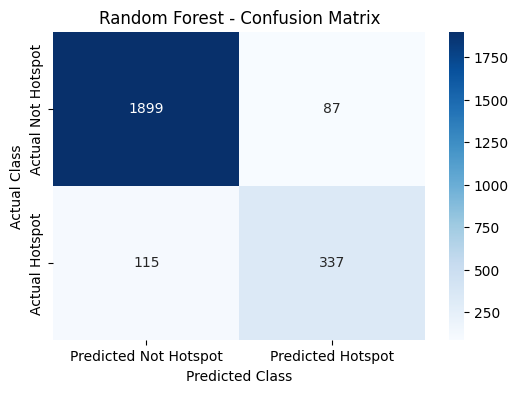

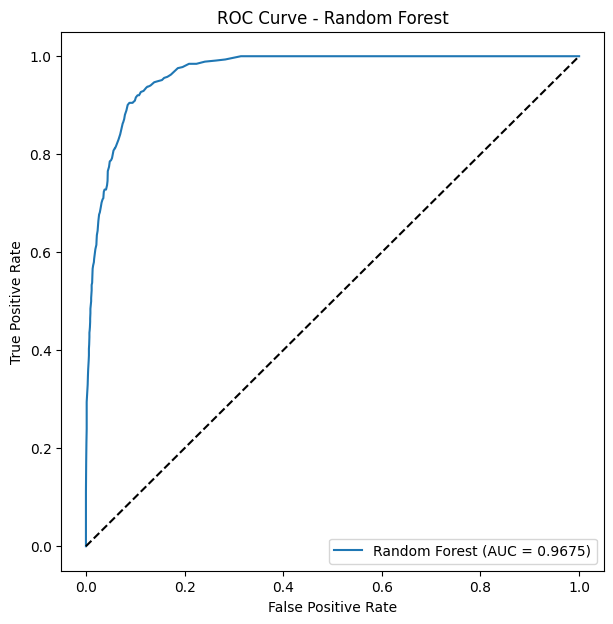

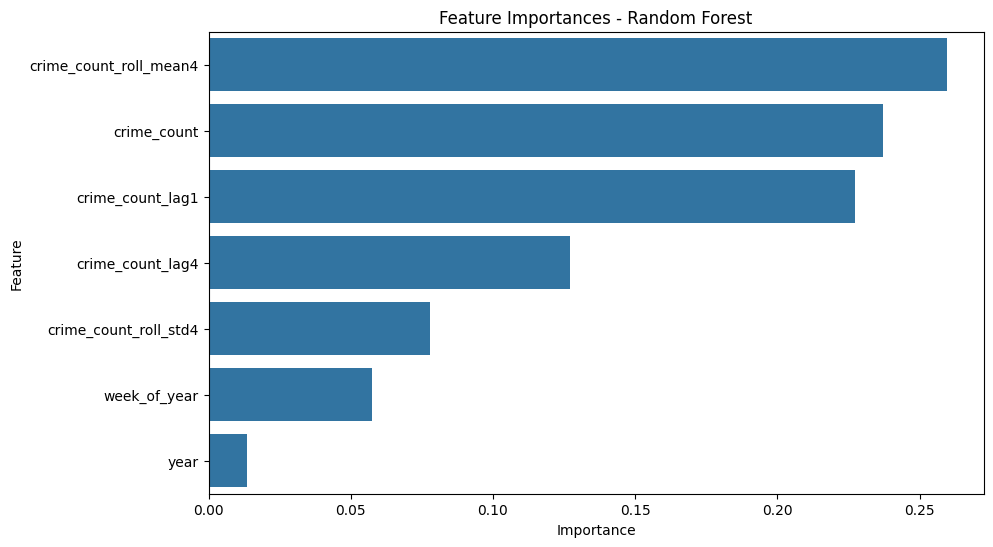

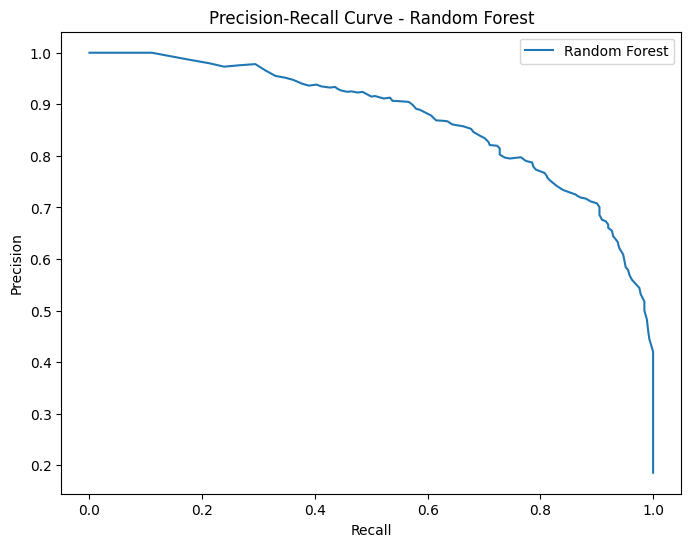

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Hotspot', 'Predicted Hotspot'],
            yticklabels=['Actual Not Hotspot', 'Actual Hotspot'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')



fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 7))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()



feature_importances = rf_model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')



precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label='Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.show()



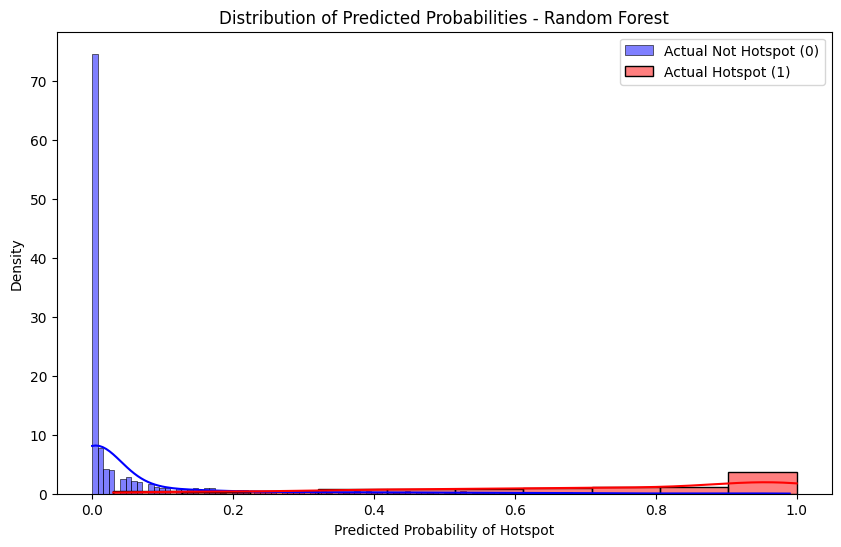

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(y_prob_rf[y_test == 0], label='Actual Not Hotspot (0)', color='blue', kde=True, stat="density", common_norm=False)
sns.histplot(y_prob_rf[y_test == 1], label='Actual Hotspot (1)', color='red', kde=True, stat="density", common_norm=False)
plt.title('Distribution of Predicted Probabilities - Random Forest')
plt.xlabel('Predicted Probability of Hotspot')
plt.ylabel('Density')
plt.legend()
plt.show()

XGBoost Classifier


In [ ]:
print("\n--- Training XGBoost Classifier ---")

# 1. Handle Class Imbalance for XGBoost

count_neg = np.sum(y_train == 0)
count_pos = np.sum(y_train == 1)

scale_pos_weight_value = count_neg / count_pos if count_pos > 0 else 1
print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight_value:.2f}")

# 2. Initialize the Model
print("Initializing XGBClassifier...")
xgb_model = XGBClassifier(
    objective='binary:logistic',    # Objective for binary classification
    scale_pos_weight=scale_pos_weight_value, # for handling class imbalance
    use_label_encoder=False,        # Recommended to avoid potential issues with older XGBoost versions

    eval_metric='logloss',          # Metric for internal evaluation/early stopping (
    random_state=42,                # For reproducibility
    n_jobs=-1                       # Use all available CPU cores

)

# 3. Train the Model
print("Training the model on X_train, y_train...")
xgb_model.fit(X_train, y_train)
print("Training complete.")

# 4. Make Predictions on the Test Set
print("\nMaking predictions on the test set (X_test)...")
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("Predictions complete.")

# 5. Evaluate the Model
print("\n--- Evaluating XGBoost Performance ---")

# Accuracy Score
try:
    accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
    print(f"Accuracy: {accuracy_xgb:.4f}")
except Exception as e:
    print(f"Error calculating Accuracy: {e}")

# Confusion Matrix
try:
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    print("\nConfusion Matrix:")
    # TN | FP
    # FN | TP
    print(cm_xgb)
except Exception as e:
    print(f"Error calculating Confusion Matrix: {e}")

# Classification Report
try:
    cr_xgb = classification_report(y_test, y_pred_xgb, target_names=['Not Hotspot (0)', 'Hotspot (1)'])
    print("\nClassification Report:")
    print(cr_xgb)
except Exception as e:
    print(f"Error calculating Classification Report: {e}")

# ROC AUC Score
try:
    auc_xgb = roc_auc_score(y_test, y_prob_xgb)
    print(f"\nROC AUC Score: {auc_xgb:.4f}")
except Exception as e:
    print(f"Error calculating ROC AUC Score: {e}")


--- Training XGBoost Classifier ---
Calculated scale_pos_weight for XGBoost: 3.67
Initializing XGBClassifier...
Training the model on X_train, y_train...
Training complete.

Making predictions on the test set (X_test)...
Predictions complete.

--- Evaluating XGBoost Performance ---
Accuracy: 0.9118

Confusion Matrix:
[[1846  140]
 [  75  377]]

Classification Report:
                 precision    recall  f1-score   support

Not Hotspot (0)       0.96      0.93      0.94      1986
    Hotspot (1)       0.73      0.83      0.78       452

       accuracy                           0.91      2438
      macro avg       0.85      0.88      0.86      2438
   weighted avg       0.92      0.91      0.91      2438


ROC AUC Score: 0.9640


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:11:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


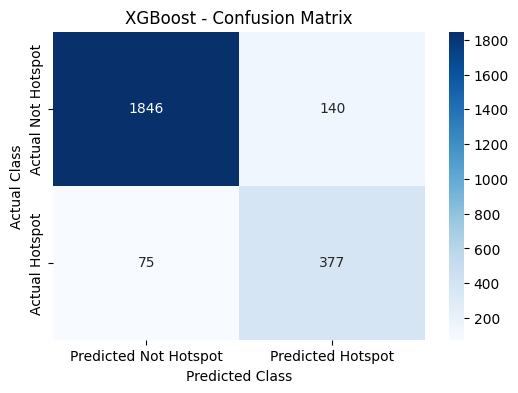

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Hotspot', 'Predicted Hotspot'],
            yticklabels=['Actual Not Hotspot', 'Actual Hotspot'])
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

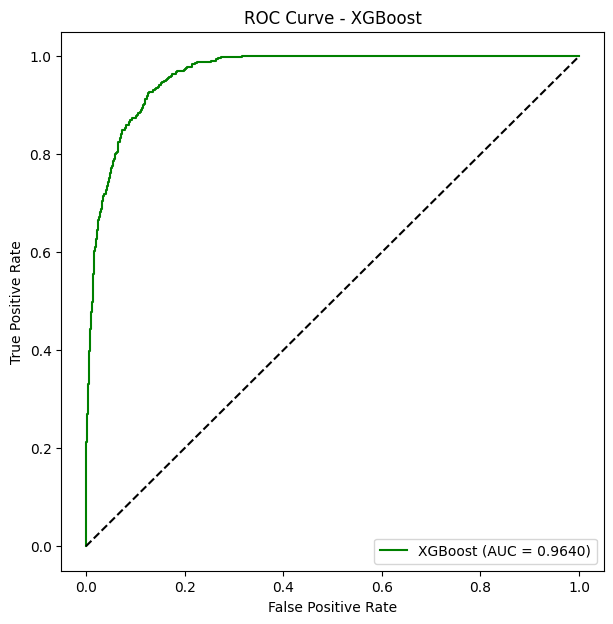

In [ ]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(7, 7))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()